In [1]:
import os
import math
import random
import joblib
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.patches import Patch
from tqdm import tqdm
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from torch.utils.data import Dataset, DataLoader
from transformers import get_cosine_schedule_with_warmup

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

# ── Paths ─────────────────────────────────────────────────────────────────────
DATA_PATH = '/kaggle/input/datasets/mohammadhossein77/ili-data/US_FLURATIO_Week.csv'
LOG_DIR   = '/kaggle/working/logs'
os.makedirs(LOG_DIR, exist_ok=True)

Device: cuda


# Init

In [2]:
LOOKBACK           = 36
HORIZON            = 12
BATCH_SIZE         = 32    # no BERT — larger batch is fine
ACCUMULATION_STEPS = 1     # effective batch = 32
EPOCHS             = 120
PATIENCE           = 10
WARMUP_EPOCHS      = 10
LR                 = 1e-4
SEED               = 42

# iTransformer-specific
D_MODEL    = 512    # each variate token dimension
N_HEADS    = 4      # head_dim = 128/4 = 32
NUM_LAYERS = 3
D_FF       = 256    # feedforward dim
DROPOUT    = 0.15

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

In [3]:
df = pd.read_csv(DATA_PATH)
print(f'Raw shape: {df.shape}')

numeric_df = df.iloc[:, :-4].copy()
numeric_df.drop(['date'], axis=1, inplace=True, errors='ignore')
numeric_df['start_date'] = pd.to_datetime(numeric_df['start_date'])
numeric_df['end_date']   = pd.to_datetime(numeric_df['end_date'])

numeric_df['WEEK_sin'] = np.sin(2 * np.pi * (numeric_df['WEEK'] / 52))
numeric_df['WEEK_cos'] = np.cos(2 * np.pi * (numeric_df['WEEK'] / 52))
numeric_df.drop(['WEEK'], axis=1, inplace=True)

numeric_df.drop(['REGION TYPE', 'REGION', 'YEAR_WEEK'],
                axis=1, inplace=True, errors='ignore')
numeric_df.drop(['prior_history_std', 'prior_history_avg'],
                axis=1, inplace=True, errors='ignore')

Raw shape: (1389, 25)


In [4]:
numeric_df = numeric_df.replace('X', np.nan)

num_features = [
    'YEAR', 'WEEK_sin', 'WEEK_cos',
    '% WEIGHTED ILI',
    'AGE 0-4', 'AGE 5-24',
    'AGE 25-49', 'AGE 25-64', 'AGE 50-64', 'AGE 65',
    'ILITOTAL', 'NUM. OF PROVIDERS', 'TOTAL PATIENTS'
]
numeric_df[num_features] = numeric_df[num_features].apply(
    pd.to_numeric, errors='coerce')

merged_df = numeric_df.copy()
merged_df.sort_values('start_date', inplace=True)
print(f'Merged shape: {merged_df.shape}')

Merged shape: (1389, 16)


In [5]:
n          = len(merged_df)
train_size = int(n * 0.8)
val_size   = int(n * 0.1)

train_df = merged_df.iloc[:train_size].copy()
val_df   = merged_df.iloc[train_size : train_size + val_size].copy()
test_df  = merged_df.iloc[train_size + val_size:].copy()
print(f'Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}')

Train: 1111 | Val: 138 | Test: 140


In [6]:
for dff in [train_df, val_df, test_df]:
    mask_split = (dff['AGE 25-49'].isna() &
                  dff['AGE 50-64'].isna() &
                  ~dff['AGE 25-64'].isna())
    dff.loc[mask_split, 'AGE 25-49'] = dff.loc[mask_split, 'AGE 25-64'] * 0.6
    dff.loc[mask_split, 'AGE 50-64'] = dff.loc[mask_split, 'AGE 25-64'] * 0.4

    mask_comb = (~dff['AGE 25-49'].isna() &
                 ~dff['AGE 50-64'].isna() &
                 dff['AGE 25-64'].isna())
    dff.loc[mask_comb, 'AGE 25-64'] = (dff.loc[mask_comb, 'AGE 25-49'] +
                                        dff.loc[mask_comb, 'AGE 50-64'])

print('NaNs after imputation (train):')
print(train_df[num_features].isna().sum())

NaNs after imputation (train):
YEAR                 0
WEEK_sin             0
WEEK_cos             0
% WEIGHTED ILI       0
AGE 0-4              0
AGE 5-24             0
AGE 25-49            0
AGE 25-64            0
AGE 50-64            0
AGE 65               0
ILITOTAL             0
NUM. OF PROVIDERS    0
TOTAL PATIENTS       0
dtype: int64


In [7]:
feature_scaler = MinMaxScaler()
train_df[num_features] = feature_scaler.fit_transform(train_df[num_features])
val_df[num_features]   = feature_scaler.transform(val_df[num_features])
test_df[num_features]  = feature_scaler.transform(test_df[num_features])
joblib.dump(feature_scaler,
            os.path.join(LOG_DIR, 'itransformer_feature_scaler.pkl'))

target_scaler = MinMaxScaler()
train_df['OT'] = target_scaler.fit_transform(
    train_df['OT'].values.reshape(-1, 1)).flatten()
val_df['OT']   = target_scaler.transform(
    val_df['OT'].values.reshape(-1, 1)).flatten()
test_df['OT']  = target_scaler.transform(
    test_df['OT'].values.reshape(-1, 1)).flatten()
joblib.dump(target_scaler,
            os.path.join(LOG_DIR, 'itransformer_target_scaler.pkl'))

if 'OT' not in num_features:
    num_features.append('OT')
print(f'Total numerical features (incl. OT): {len(num_features)}')  # 14

Total numerical features (incl. OT): 14


In [8]:
def create_sequences(df, lookback, horizon):
    df = df.sort_values('start_date').reset_index(drop=True)
    X, y = [], []
    for i in range(len(df) - lookback - horizon + 1):
        X.append(df[num_features].iloc[i : i + lookback].values)   # (36, 14)
        y.append(df['OT'].iloc[i + lookback : i + lookback + horizon].values)
    return (np.array(X, dtype=np.float32),
            np.array(y, dtype=np.float32))


val_df_full  = pd.concat([train_df.iloc[-LOOKBACK:], val_df],  ignore_index=True)
test_df_full = pd.concat([val_df.iloc[-LOOKBACK:],  test_df],  ignore_index=True)

X_train, y_train = create_sequences(train_df,     LOOKBACK, HORIZON)
X_val,   y_val   = create_sequences(val_df_full,  LOOKBACK, HORIZON)
X_test,  y_test  = create_sequences(test_df_full, LOOKBACK, HORIZON)

print(f'Train : {X_train.shape} -> {y_train.shape}')
print(f'Val   : {X_val.shape}   -> {y_val.shape}')
print(f'Test  : {X_test.shape}  -> {y_test.shape}')

Train : (1064, 36, 14) -> (1064, 12)
Val   : (127, 36, 14)   -> (127, 12)
Test  : (129, 36, 14)  -> (129, 12)


In [9]:
class NumericalDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


train_loader = DataLoader(NumericalDataset(X_train, y_train),
                          batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(NumericalDataset(X_val,   y_val),
                          batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(NumericalDataset(X_test,  y_test),
                          batch_size=BATCH_SIZE, shuffle=False)

print(f'Batches — Train: {len(train_loader)} | '
      f'Val: {len(val_loader)} | Test: {len(test_loader)}')

Batches — Train: 34 | Val: 4 | Test: 5


# iTransformer

In [10]:
# =============================================================================
# 3. iTransformer Model
#    Key idea (Liu et al., ICLR 2024):
#      - Transpose the input: treat each variate's full time series as ONE token
#      - Transformer attends ACROSS variates (not across time steps)
#      - Each variate token independently predicts the horizon via a shared head
#      - Only OT variate's output is returned as the final forecast
#
#    Input  : (B, T, C) = (B, 36, 14)
#    Tokens : (B, C, D) = (B, 14, 128) — one token per variate
#    Output : (B, horizon) — OT channel only
# =============================================================================

class iTransformer(nn.Module):
    def __init__(self,
                 seq_len      = 36,
                 horizon      = 12,
                 num_variates = 14,
                 d_model      = 128,
                 n_heads      = 4,
                 num_layers   = 3,
                 d_ff         = 256,
                 dropout      = 0.15):
        super().__init__()

        self.num_variates = num_variates
        self.ot_idx       = num_variates - 1   # OT is last column
        self.d_model      = d_model

        # ── Variate embedding: project each variate's T-length series → d_model
        # Each variate's entire 36-week history becomes a single d_model vector
        self.variate_proj = nn.Linear(seq_len, d_model)

        # ── Transformer encoder: attends across the C=14 variate tokens ────────
        # Pre-LN (norm_first=True) for training stability
        encoder_layer = nn.TransformerEncoderLayer(
            d_model         = d_model,
            nhead           = n_heads,
            dim_feedforward = d_ff,
            dropout         = dropout,
            batch_first     = True,
            norm_first      = True,
        )
        self.transformer = nn.TransformerEncoder(
            encoder_layer, num_layers=num_layers)

        self.norm = nn.LayerNorm(d_model)

        # ── Prediction head: each variate token → horizon independently ────────
        # Applied identically to every variate; only OT output is used
        self.head = nn.Sequential(
            nn.Linear(d_model, d_model),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, horizon),
        )

    def forward(self, x):              # x: (B, T, C)
        B, T, C = x.shape

        # ── 1. Transpose → (B, C, T): variates become the sequence dimension ──
        x = x.transpose(1, 2)         # (B, C, T) = (B, 14, 36)

        # ── 2. Project each variate's T-step series to d_model ────────────────
        x = self.variate_proj(x)      # (B, C, D) = (B, 14, 128)
        # No positional encoding — variates have no natural ordering

        # ── 3. Self-attention across variates ─────────────────────────────────
        x = self.transformer(x)       # (B, C, D) — each variate attends to all others
        x = self.norm(x)              # (B, C, D)

        # ── 4. Per-variate prediction head ────────────────────────────────────
        x = self.head(x)              # (B, C, horizon)

        # ── 5. Return only OT variate's forecast ──────────────────────────────
        return x[:, self.ot_idx, :]   # (B, horizon)



In [11]:
model = iTransformer(
    seq_len      = LOOKBACK,
    horizon      = HORIZON,
    num_variates = len(num_features),  # 14
    d_model      = D_MODEL,
    n_heads      = N_HEADS,
    num_layers   = NUM_LAYERS,
    d_ff         = D_FF,
    dropout      = DROPOUT,
).to(device)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f'Trainable params: {trainable:,} / Total: {total:,}')

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LR,
    weight_decay=1e-4
)

updates_per_epoch = math.ceil(len(train_loader) / ACCUMULATION_STEPS)
scheduler = get_cosine_schedule_with_warmup(
    optimizer,
    num_warmup_steps   = WARMUP_EPOCHS * updates_per_epoch,
    num_training_steps = EPOCHS        * updates_per_epoch,
)

criterion = nn.MSELoss()


/tmp/ipykernel_58/511524557.py:44: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(


Trainable params: 4,235,532 / Total: 4,235,532


# Training

In [12]:
history         = {'epoch': [], 'train_loss': [], 'val_loss': []}
best_val_loss   = float('inf')
best_model_path = os.path.join(LOG_DIR, 'itransformer_best.pth')
p_counter       = 0

for epoch in tqdm(range(EPOCHS)):

    # ── Train ──────────────────────────────────────────────────────────────────
    model.train()
    optimizer.zero_grad()
    epoch_train_loss = 0.0

    for batch_idx, (X_b, y_b) in enumerate(train_loader):
        X_b = X_b.to(device)
        y_b = y_b.to(device)

        preds = model(X_b)
        loss  = criterion(preds, y_b) / ACCUMULATION_STEPS
        loss.backward()

        if ((batch_idx + 1) % ACCUMULATION_STEPS == 0 or
                (batch_idx + 1) == len(train_loader)):
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()
            optimizer.zero_grad()

        epoch_train_loss += loss.item() * ACCUMULATION_STEPS

    avg_train = epoch_train_loss / len(train_loader)

    # ── Validate ───────────────────────────────────────────────────────────────
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for X_b, y_b in val_loader:
            X_b       = X_b.to(device)
            y_b       = y_b.to(device)
            preds     = model(X_b)
            val_loss += criterion(preds, y_b).item()

    avg_val = val_loss / len(val_loader)

    history['epoch'].append(epoch)
    history['train_loss'].append(avg_train)
    history['val_loss'].append(avg_val)

    if avg_val < best_val_loss:
        best_val_loss = avg_val
        p_counter     = 0
        torch.save(model.state_dict(), best_model_path)
        print(f'  ↓ New best at epoch {epoch} | val={avg_val:.6f}')
    else:
        if epoch >= WARMUP_EPOCHS:
            p_counter += 1
            if p_counter >= PATIENCE:
                print(f'Early stopping at epoch {epoch}')
                break

    if epoch % 10 == 0 or epoch < 5:
        print(f'Epoch {epoch:3d} | Train: {avg_train:.6f} | Val: {avg_val:.6f}')

print(f'\nBest val loss : {best_val_loss:.6f}')
print(f'Checkpoint    : {best_model_path}')

  1%|          | 1/120 [00:01<02:18,  1.16s/it]

  ↓ New best at epoch 0 | val=0.051552
Epoch   0 | Train: 0.090571 | Val: 0.051552


  2%|▏         | 2/120 [00:01<01:23,  1.41it/s]

  ↓ New best at epoch 1 | val=0.033793
Epoch   1 | Train: 0.032696 | Val: 0.033793


  2%|▎         | 3/120 [00:01<01:06,  1.77it/s]

...

  ↓ New best at epoch 23 | val=0.018041


 26%|██▌       | 31/120 [00:12<00:31,  2.79it/s]

Epoch  30 | Train: 0.006811 | Val: 0.019499


 28%|██▊       | 33/120 [00:13<00:35,  2.47it/s]

Early stopping at epoch 33

Best val loss : 0.018041
Checkpoint    : /kaggle/working/logs/itransformer_best.pth


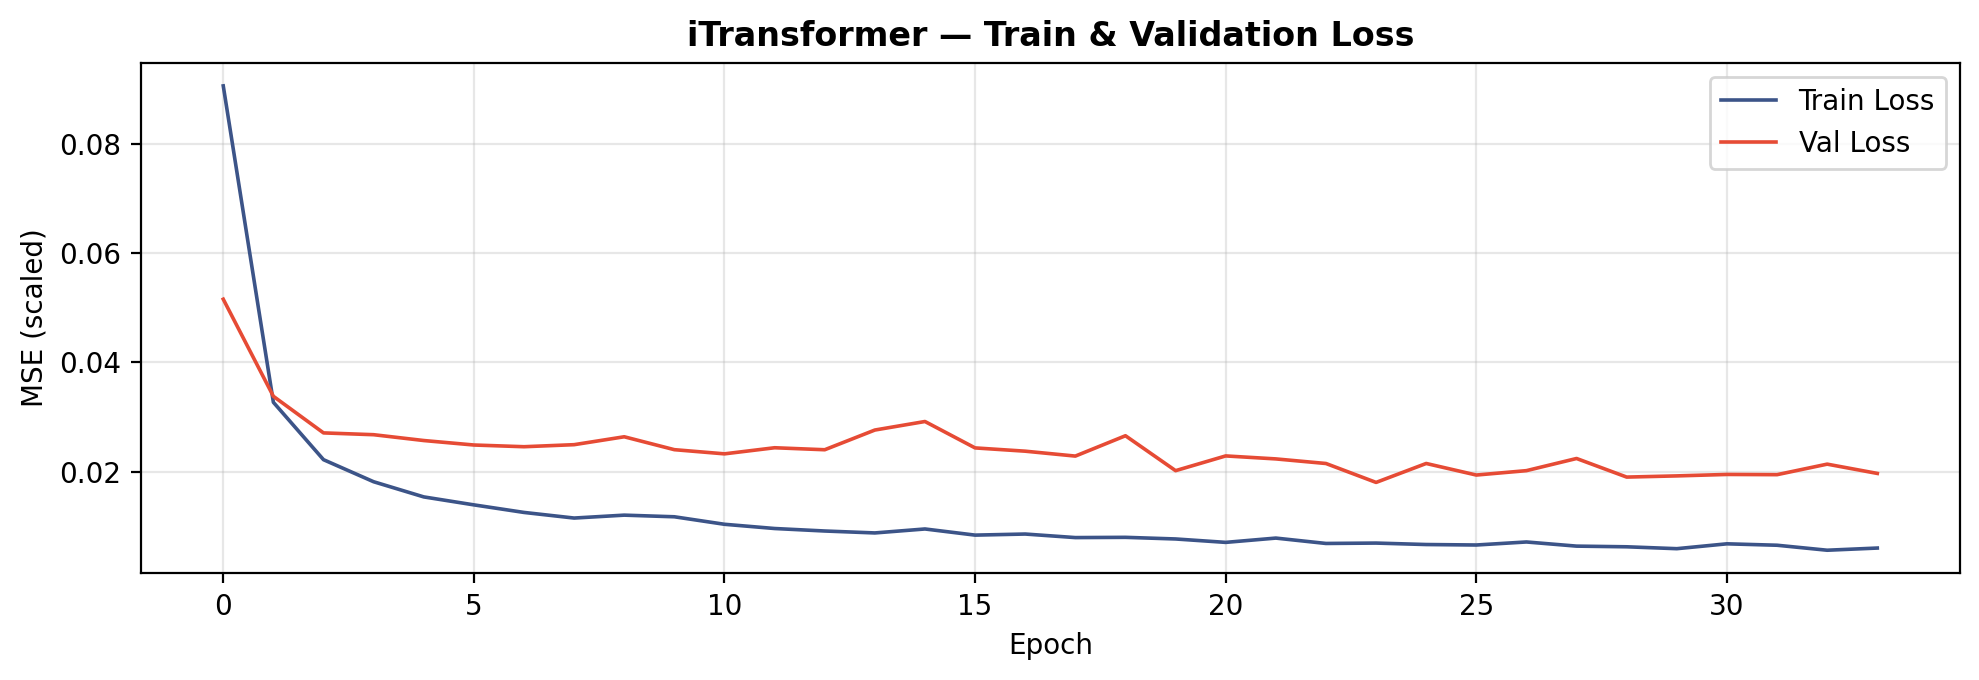

In [13]:
mpl.rcParams.update({'font.family': 'DejaVu Sans',
                     'axes.facecolor': 'white', 'figure.facecolor': 'white'})
plt.figure(figsize=(10, 3.5), dpi=200)
plt.plot(history['epoch'], history['train_loss'],
         color='#3C5488', label='Train Loss', linewidth=1.3)
plt.plot(history['epoch'], history['val_loss'],
         color='#E64B35', label='Val Loss',   linewidth=1.3)
plt.xlabel('Epoch'); plt.ylabel('MSE (scaled)')
plt.title('iTransformer — Train & Validation Loss', fontweight='bold')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig(f'{LOG_DIR}/itransformer_loss_curve.png',
            dpi=300, bbox_inches='tight')
plt.show()

In [14]:
model.load_state_dict(torch.load(best_model_path, map_location=device))
model.eval()

test_preds, test_targets = [], []
with torch.no_grad():
    for X_b, y_b in test_loader:
        X_b   = X_b.to(device)
        preds = model(X_b)
        test_preds.extend(preds.cpu().numpy())
        test_targets.extend(y_b.numpy())

test_preds   = np.array(test_preds)    # (N, 12)
test_targets = np.array(test_targets)  # (N, 12)

inv_preds   = target_scaler.inverse_transform(
    test_preds.reshape(-1, 1)).reshape(-1, HORIZON)
inv_targets = target_scaler.inverse_transform(
    test_targets.reshape(-1, 1)).reshape(-1, HORIZON)

mse_val  = mean_squared_error(inv_targets.flatten(), inv_preds.flatten())
mae_val  = mean_absolute_error(inv_targets.flatten(), inv_preds.flatten())
rmse_val = np.sqrt(mse_val)

print('=' * 60)
print(f'  iTransformer (unimodal) | Test MSE : {mse_val:.4f}')
print(f'                          | Test MAE : {mae_val:.4f}')
print(f'                          | Test RMSE: {rmse_val:.4f}  (inverse-scaled)')
print(f'  PatchTST (unimodal)     | Test MSE : 1.55')
print(f'  DLinear  (unimodal)     | Test MSE : 1.6642')
print(f'  DSA      (mean / best)  | Test MSE : 1.120 ± 0.096 / 0.9749')
print('=' * 60)



  iTransformer (unimodal) | Test MSE : 1.1111
                          | Test MAE : 0.7362
                          | Test RMSE: 1.0541  (inverse-scaled)
  PatchTST (unimodal)     | Test MSE : 1.55
  DLinear  (unimodal)     | Test MSE : 1.6642
  DSA      (mean / best)  | Test MSE : 1.120 ± 0.096 / 0.9749


In [15]:
# ── Per-sample & per-horizon errors ───────────────────────────────────────────
per_sample_mse  = ((inv_preds - inv_targets) ** 2).mean(axis=1)   # (N,)
per_horizon_mse = ((inv_preds - inv_targets) ** 2).mean(axis=0)   # (12,)

np.save(f'{LOG_DIR}/errors_itransformer.npy',  per_sample_mse)
np.save(f'{LOG_DIR}/horizon_itransformer.npy', per_horizon_mse)
np.save(f'{LOG_DIR}/preds_itransformer.npy',   inv_preds)
np.save(f'{LOG_DIR}/targets_itransformer.npy', inv_targets)

print('\nPer-horizon MSE (weeks 1–12):')
for h, hmse in enumerate(per_horizon_mse, 1):
    print(f'  Week {h:2d}: {hmse:.4f}')


Per-horizon MSE (weeks 1–12):
  Week  1: 0.3794
  Week  2: 0.4554
  Week  3: 0.6401
  Week  4: 0.7556
  Week  5: 0.9133
  Week  6: 1.0925
  Week  7: 1.2938
  Week  8: 1.4320
  Week  9: 1.6546
  Week 10: 1.5036
  Week 11: 1.6485
  Week 12: 1.5639


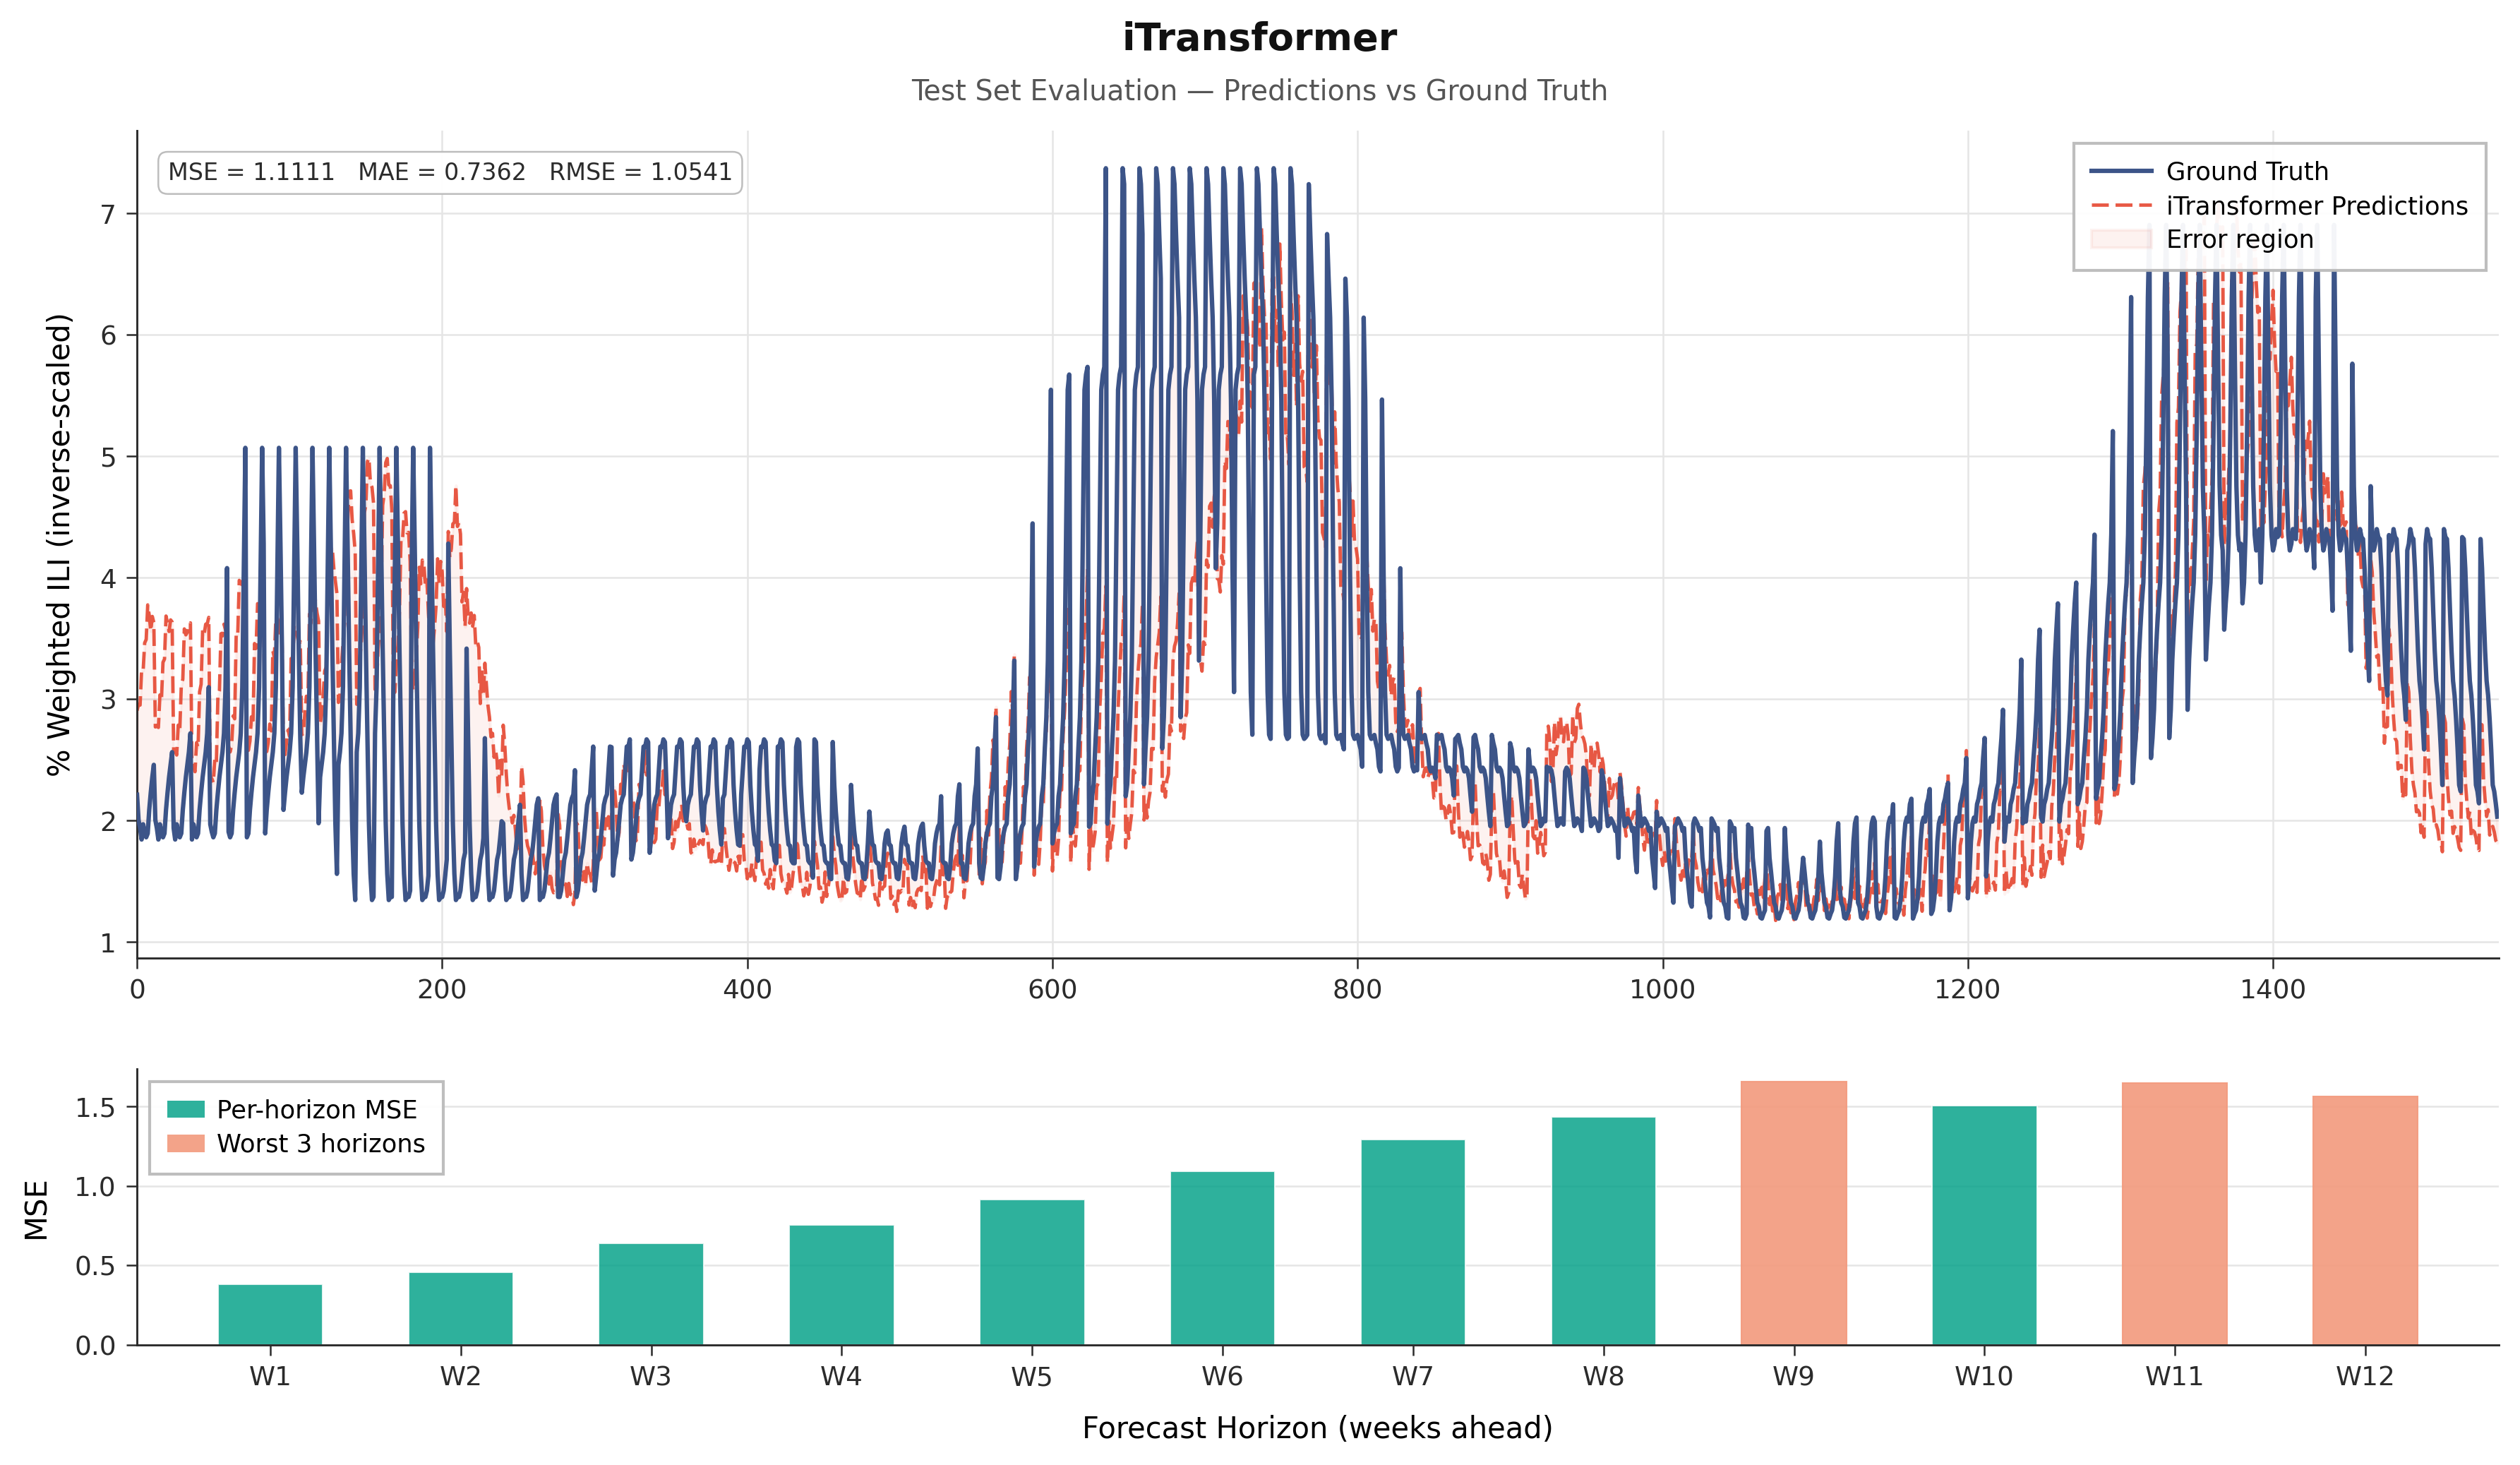

Done. All outputs saved to /kaggle/working/logs


In [16]:
C_TRUTH  = '#3C5488'
C_PRED   = '#E64B35'
C_FILL   = '#E64B35'
C_BAR    = '#00A087'
C_WORST  = '#F39B7F'
C_GRID   = '#E5E5E5'

mpl.rcParams.update({
    'font.family': 'DejaVu Sans', 'font.size': 10,
    'axes.linewidth': 0.7,  'axes.edgecolor': '#2B2B2B',
    'axes.facecolor': 'white', 'figure.facecolor': 'white',
    'xtick.major.width': 0.6, 'ytick.major.width': 0.6,
    'xtick.major.size': 3.5,  'ytick.major.size': 3.5,
    'xtick.direction': 'out', 'ytick.direction': 'out',
    'xtick.color': '#2B2B2B', 'ytick.color': '#2B2B2B',
    'legend.framealpha': 0.95, 'legend.edgecolor': '#BBBBBB',
    'legend.fancybox': False,
})

flat_targets = inv_targets.flatten()
flat_preds   = inv_preds.flatten()
timesteps    = np.arange(len(flat_targets))

fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(12, 6.5), dpi=300,
    gridspec_kw={'height_ratios': [3, 1]}
)
fig.text(0.5, 1.03, 'iTransformer',
         ha='center', va='bottom',
         fontsize=13, fontweight='bold', color='#111111')
fig.text(0.5, 0.995, 'Test Set Evaluation — Predictions vs Ground Truth',
         ha='center', va='bottom',
         fontsize=9.5, fontweight='normal', color='#555555')

ax1.plot(timesteps, flat_targets,
         color=C_TRUTH, linewidth=1.5, alpha=1.0,
         label='Ground Truth', zorder=3)
ax1.plot(timesteps, flat_preds,
         color=C_PRED, linewidth=1.15, linestyle='--', dashes=(5, 2),
         alpha=0.92, label='iTransformer Predictions', zorder=2)
ax1.fill_between(timesteps, flat_targets, flat_preds,
                 color=C_FILL, alpha=0.07, zorder=1, label='Error region')
ax1.set_ylabel('% Weighted ILI (inverse-scaled)', fontsize=10, labelpad=8)
ax1.set_xlim(0, len(flat_targets))
ax1.grid(True, color=C_GRID, linewidth=0.6)
ax1.set_axisbelow(True)
ax1.spines[['top', 'right']].set_visible(False)
ax1.tick_params(axis='both', labelsize=9)
ax1.legend(loc='upper right', fontsize=8.5, handlelength=2.4,
           handletextpad=0.6, borderpad=0.7, labelspacing=0.4)
ax1.text(0.013, 0.963,
         f'MSE = {mse_val:.4f}   MAE = {mae_val:.4f}   RMSE = {rmse_val:.4f}',
         transform=ax1.transAxes, fontsize=8,
         verticalalignment='top', color='#2B2B2B',
         bbox=dict(boxstyle='round,pad=0.40', facecolor='white',
                   edgecolor='#BBBBBB', linewidth=0.6, alpha=0.97))

horizon_steps = np.arange(1, 13)
bars = ax2.bar(horizon_steps, per_horizon_mse,
               color=C_BAR, alpha=0.82, width=0.55,
               edgecolor='white', linewidth=0.5, zorder=2)
top3_idx = np.argsort(per_horizon_mse)[-3:]
for idx in top3_idx:
    bars[idx].set_color(C_WORST)
    bars[idx].set_alpha(0.92)

ax2.set_xlabel('Forecast Horizon (weeks ahead)', fontsize=10, labelpad=8)
ax2.set_ylabel('MSE', fontsize=10, labelpad=8)
ax2.set_xticks(horizon_steps)
ax2.set_xticklabels([f'W{h}' for h in horizon_steps], fontsize=8.5)
ax2.grid(axis='y', color=C_GRID, linewidth=0.6)
ax2.set_axisbelow(True)
ax2.set_xlim(0.3, 12.7)
ax2.tick_params(axis='both', labelsize=9)
ax2.spines[['top', 'right']].set_visible(False)
ax2.legend(handles=[
    Patch(facecolor=C_BAR,   alpha=0.82, label='Per-horizon MSE'),
    Patch(facecolor=C_WORST, alpha=0.92, label='Worst 3 horizons'),
], fontsize=8.5, loc='upper left', handlelength=1.5,
   handletextpad=0.5, borderpad=0.7, labelspacing=0.4)

plt.tight_layout(h_pad=2.2)
plt.savefig(f'{LOG_DIR}/itransformer_test_evaluation.png',
            dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print('Done. All outputs saved to', LOG_DIR)

In [17]:
# !rm -rf kaggle/working/*

- Test MSE : 1.6897
                (seq_len      = 36,
                 horizon      = 12,
                 num_variates = 14,
                 d_model      = 128,
                 n_heads      = 4,
                 num_layers   = 3,
                 d_ff         = 256,
                 dropout      = 0.15)

- Test MSE : 1.5470
                (seq_len      = 36,
                 horizon      = 12,
                 num_variates = 14,
                 d_model      = 256,
                 n_heads      = 4,
                 num_layers   = 3,
                 d_ff         = 256,
                 dropout      = 0.15)

- Test MSE : 1.1111
                (seq_len      = 36,
                 horizon      = 12,
                 num_variates = 14,
                 d_model      = 512,
                 n_heads      = 4,
                 num_layers   = 3,
                 d_ff         = 256,
                 dropout      = 0.15)

======================================================================================================
- Larger values for "d_model" leads to overfit.
- Larger values for "n_heads" leads to overfit.
- Larger values for "num_layers" leads to overfit.
- Larger values for "d_ff" leads to overfit.